# 05 — Hyperparameter tuning (training data only)

**The test set is final and is not loaded in this notebook.** All decisions use the training set.

**Method**
1. **Search** each model's small hyperparameter space with stratified 5-fold CV on its own seed (`TUNING_CV_SEED`), ranking by ROC-AUC (PR-AUC also recorded). Search spaces live in `src/churn/tuning.py`.
2. **Re-evaluate** each model's best setting on the *same* repeated 5-fold × 3 folds used for the Phase 5 baselines, so tuned and baseline models can be compared fold-by-fold (paired).
3. Pick the final candidate and re-select the threshold on out-of-fold predictions with the Phase 6 rule.

Using separate folds for searching and comparing reduces, but does not remove, the optimism of picking the best of several configurations on the same data; small search spaces keep it limited.

**Selection rule (stated before results):** the candidate with the highest evaluation-fold ROC-AUC, unless its paired advantage over tuned Logistic Regression is under 2 standard errors — then tuned Logistic Regression is kept (simpler, better calibrated, directly interpretable).

In [1]:
import json
import time
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from churn.config import FIGURES_DIR, REPORTS_DIR
from churn.data import load_dataset, split_features_target, split_train_test
from churn.evaluation import classification_metrics, select_threshold_min_recall, threshold_table
from churn.modeling import cross_validate_models
from churn.tuning import SEARCH_SPACES, TUNING_CV_SEED, make_tuned_pipeline, tune_model

%matplotlib inline
pd.set_option("display.precision", 4)
pd.set_option("display.max_colwidth", 120)

TEXT, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": TEXT,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10, "legend.frameon": False,
})

## 1. Training data

In [2]:
train_df, _ = split_train_test(load_dataset())  # test half discarded, never used here
X_train, y_train = split_features_target(train_df)
print(f"Training rows: {len(X_train)}, churn rate {y_train.mean():.2%}; tuning CV seed {TUNING_CV_SEED}")

Training rows: 5634, churn rate 26.54%; tuning CV seed 43


## 2. Hyperparameter search

In [3]:
MODELS = ["LogisticRegression", "HistGradientBoosting", "RandomForest"]
tuning_results = {}
for name in MODELS:
    start = time.perf_counter()
    tuning_results[name] = tune_model(name, X_train, y_train)
    print(f"{name}: {len(tuning_results[name].results)} candidates in {time.perf_counter() - start:.0f}s")

all_candidates = pd.concat(
    [r.results.assign(model=name, rank=range(1, len(r.results) + 1)) for name, r in tuning_results.items()]
)
all_candidates.assign(params=all_candidates["params"].astype(str)).to_csv(
    REPORTS_DIR / "tuning_search_results.csv", index=False)

LogisticRegression: 18 candidates in 10s
HistGradientBoosting: 25 candidates in 29s
RandomForest: 15 candidates in 41s


In [4]:
for name, result in tuning_results.items():
    print(f"\n=== {name}: top 5 of {len(result.results)} ===")
    display(result.results.head(5))


=== LogisticRegression: top 5 of 18 ===


,params,cv_roc_auc,cv_roc_auc_std,cv_pr_auc,train_roc_auc,overfit_gap
0,"{'model__C': 10.0, 'model__l1_ratio': 0.0, 'model__solver': 'liblinear'}",0.8462,0.0057,0.6606,0.8499,0.0037
1,"{'model__C': 10.0, 'model__l1_ratio': 1.0, 'model__solver': 'liblinear'}",0.8461,0.0056,0.6606,0.8499,0.0038
2,"{'model__C': 3.0, 'model__l1_ratio': 0.0, 'model__solver': 'liblinear'}",0.8461,0.0056,0.6615,0.8498,0.0037
3,"{'model__C': 3.0, 'model__l1_ratio': 1.0, 'model__solver': 'liblinear'}",0.8460,0.0056,0.6616,0.8497,0.0037
4,"{'model__C': 1.0, 'model__l1_ratio': 0.0, 'model__solver': 'liblinear'}",0.8460,0.0056,0.6620,0.8496,0.0036



=== HistGradientBoosting: top 5 of 25 ===


,params,cv_roc_auc,cv_roc_auc_std,cv_pr_auc,train_roc_auc,overfit_gap
0,"{'model__l2_regularization': 5.626265699005659, 'model__learning_rate': 0.015836308681309343, 'model__max_depth': 5,...",0.8489,0.0031,0.6684,0.8655,0.0166
1,"{'model__l2_regularization': 3.8088682665730316, 'model__learning_rate': 0.024245851884448708, 'model__max_depth': 5...",0.8484,0.0038,0.6700,0.8707,0.0222
2,"{'model__l2_regularization': 0.23950484068646463, 'model__learning_rate': 0.021186133036143917, 'model__max_depth': ...",0.8481,0.0034,0.6657,0.8640,0.0159
3,"{'model__l2_regularization': 4.925187130911159, 'model__learning_rate': 0.02197582907524181, 'model__max_depth': Non...",0.8481,0.0043,0.6682,0.8844,0.0363
4,"{'model__l2_regularization': 4.490097752113332, 'model__learning_rate': 0.012328680151983719, 'model__max_depth': 5,...",0.8477,0.0041,0.6652,0.8822,0.0345



=== RandomForest: top 5 of 15 ===


,params,cv_roc_auc,cv_roc_auc_std,cv_pr_auc,train_roc_auc,overfit_gap
0,"{'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_jobs': 1}",0.8479,0.0045,0.6636,0.8797,0.0318
1,"{'model__max_features': 0.3, 'model__min_samples_leaf': 50, 'model__n_jobs': 1}",0.8471,0.0041,0.6618,0.8655,0.0184
2,"{'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_jobs': 1}",0.8470,0.0037,0.6634,0.9019,0.0549
3,"{'model__max_features': 0.3, 'model__min_samples_leaf': 20, 'model__n_jobs': 1}",0.8470,0.0036,0.6639,0.8874,0.0404
4,"{'model__max_features': 'sqrt', 'model__min_samples_leaf': 50, 'model__n_jobs': 1}",0.8465,0.0056,0.6599,0.8617,0.0152


In [5]:
best_params = {name: r.best_params for name, r in tuning_results.items()}
best_params

{'LogisticRegression': {'model__C': 10.0,
  'model__l1_ratio': 0.0,
  'model__solver': 'liblinear'},
 'HistGradientBoosting': {'model__l2_regularization': np.float64(5.626265699005659),
  'model__learning_rate': np.float64(0.015836308681309343),
  'model__max_depth': 5,
  'model__max_iter': 300,
  'model__max_leaf_nodes': 7,
  'model__min_samples_leaf': 200},
 'RandomForest': {'model__max_features': 'sqrt',
  'model__min_samples_leaf': 20,
  'model__n_jobs': 1}}

## 3. Tuned vs. baseline on the Phase 5 evaluation folds

In [6]:
factories = {f"{name} (tuned)": partial(make_tuned_pipeline, name, params) for name, params in best_params.items()}
start = time.perf_counter()
tuned_cv = cross_validate_models(X_train, y_train, pipeline_factories=factories)
print(f"Evaluated tuned models in {time.perf_counter() - start:.0f}s")

baseline_folds = pd.read_csv(REPORTS_DIR / "cv_baseline_fold_metrics.csv")
baseline_folds["model"] = baseline_folds["model"] + " (baseline)"
all_folds = pd.concat([baseline_folds, tuned_cv.fold_metrics], ignore_index=True)
all_folds.to_csv(REPORTS_DIR / "cv_tuned_vs_baseline_fold_metrics.csv", index=False)

metric_order = ["roc_auc", "pr_auc", "precision", "recall", "f1", "brier", "log_loss", "train_roc_auc"]
order = [f"{m} ({kind})" for m in MODELS for kind in ("baseline", "tuned")]
summary = all_folds.groupby("model")[metric_order].agg(["mean", "std"]).loc[order]
summary.to_csv(REPORTS_DIR / "cv_tuned_vs_baseline_summary.csv")

readable = pd.DataFrame({
    m: summary[(m, "mean")].map("{:.4f}".format) + " ± " + summary[(m, "std")].map("{:.4f}".format)
    for m in metric_order
})
readable["overfit_gap"] = (summary[("train_roc_auc", "mean")] - summary[("roc_auc", "mean")]).round(4)
readable

Evaluated tuned models in 27s


,roc_auc,pr_auc,precision,recall,f1,brier,log_loss,train_roc_auc,overfit_gap
model,,,,,,,,,
LogisticRegression (baseline),0.8463 ± 0.0121,0.6612 ± 0.0176,0.6543 ± 0.0253,0.5454 ± 0.0359,0.5942 ± 0.0249,0.1350 ± 0.0044,0.4169 ± 0.0136,0.8496 ± 0.0030,0.0033
LogisticRegression (tuned),0.8464 ± 0.0120,0.6604 ± 0.0169,0.6585 ± 0.0260,0.5489 ± 0.0359,0.5980 ± 0.0245,0.1349 ± 0.0044,0.4168 ± 0.0137,0.8500 ± 0.0030,0.0036
HistGradientBoosting (baseline),0.8366 ± 0.0107,0.6499 ± 0.0204,0.6429 ± 0.0241,0.5226 ± 0.0334,0.5758 ± 0.0215,0.1399 ± 0.0045,0.4352 ± 0.0165,0.9624 ± 0.0019,0.1258
HistGradientBoosting (tuned),0.8496 ± 0.0123,0.6690 ± 0.0198,0.6735 ± 0.0199,0.5269 ± 0.0365,0.5905 ± 0.0242,0.1337 ± 0.0045,0.4126 ± 0.0127,0.8652 ± 0.0028,0.0156
RandomForest (baseline),0.8263 ± 0.0134,0.6205 ± 0.0286,0.6367 ± 0.0275,0.4979 ± 0.0382,0.5582 ± 0.0299,0.1438 ± 0.0058,0.4667 ± 0.0319,1.0000 ± 0.0000,0.1736
RandomForest (tuned),0.8487 ± 0.0118,0.6645 ± 0.0213,0.6766 ± 0.0230,0.4861 ± 0.0392,0.5647 ± 0.0258,0.1344 ± 0.0040,0.4142 ± 0.0113,0.8799 ± 0.0023,0.0312


Precision / recall / F1 above are at threshold 0.5 for comparability with Phase 5; the operating threshold is chosen in section 5.

### 3.1 Paired differences

Same 15 folds for every row, so per-fold differences are paired.

In [7]:
folds = all_folds.set_index(["model", "fold"])


def paired(a, b, metrics=("roc_auc", "pr_auc", "brier", "log_loss")):
    rows = []
    for metric in metrics:
        d = folds.loc[a, metric] - folds.loc[b, metric]
        better = (d < 0) if metric in ("brier", "log_loss") else (d > 0)
        se = d.std(ddof=1) / np.sqrt(len(d))
        rows.append({"comparison": f"{a} − {b}", "metric": metric, "mean_diff": d.mean(),
                     "std_error": se, "diff / SE": d.mean() / se, "folds_better": f"{int(better.sum())}/{len(d)}"})
    return rows


comparisons = [(f"{m} (tuned)", f"{m} (baseline)") for m in MODELS]
comparisons += [(f"{m} (tuned)", "LogisticRegression (tuned)") for m in MODELS[1:]]
paired_table = pd.DataFrame([row for a, b in comparisons for row in paired(a, b)]).set_index(["comparison", "metric"])
paired_table.to_csv(REPORTS_DIR / "cv_tuned_paired_differences.csv")
paired_table

mean_diff  \
comparison                                                     metric                 
LogisticRegression (tuned) − LogisticRegression (baseline)     roc_auc   1.3973e-04   
                                                               pr_auc   -7.6646e-04   
                                                               brier    -9.7783e-05   
                                                               log_loss -1.0441e-04   
HistGradientBoosting (tuned) − HistGradientBoosting (baseline) roc_auc   1.3008e-02   
                                                               pr_auc    1.9084e-02   
                                                               brier    -6.2033e-03   
                                                               log_loss -2.2544e-02   
RandomForest (tuned) − RandomForest (baseline)                 roc_auc   2.2364e-02   
                                                               pr_auc    4.4069e-02   
                                                               brier    -9.4504e-03   
                                                               log_loss -5.2501e-02   
HistGradientBoosting (tuned) − LogisticRegression (tuned)      roc_auc   3.1429e-03   
                                                               pr_auc    8.6095e-03   
                                                               brier    -1.2154e-03   
                                                               log_loss -4.1715e-03   
RandomForest (tuned) − LogisticRegression (tuned)              roc_auc   2.2738e-03   
                                                               pr_auc    4.1483e-03   
                                                               brier    -5.4799e-04   
                                                               log_loss -2.5484e-03   

                                                                          std_error  \
comparison                                                     metric                 
LogisticRegression (tuned) − LogisticRegression (baseline)     roc_auc   1.2505e-04   
                                                               pr_auc    5.6198e-04   
                                                               brier     4.4874e-05   
                                                               log_loss  1.3372e-04   
HistGradientBoosting (tuned) − HistGradientBoosting (baseline) roc_auc   1.2250e-03   
                                                               pr_auc    2.4250e-03   
                                                               brier     4.6673e-04   
                                                               log_loss  1.6657e-03   
RandomForest (tuned) − RandomForest (baseline)                 roc_auc   2.2136e-03   
                                                               pr_auc    4.2215e-03   
                                                               brier     8.9829e-04   
                                                               log_loss  6.0611e-03   
HistGradientBoosting (tuned) − LogisticRegression (tuned)      roc_auc   9.7342e-04   
                                                               pr_auc    2.3098e-03   
                                                               brier     4.3186e-04   
                                                               log_loss  1.1133e-03   
RandomForest (tuned) − LogisticRegression (tuned)              roc_auc   1.1326e-03   
                                                               pr_auc    2.5159e-03   
                                                               brier     4.5817e-04   
                                                               log_loss  1.4294e-03   

                                                                         diff / SE  \
comparison                                                     metric                
LogisticRegression (tuned) − LogisticRegression (baseline)     roc_auc  

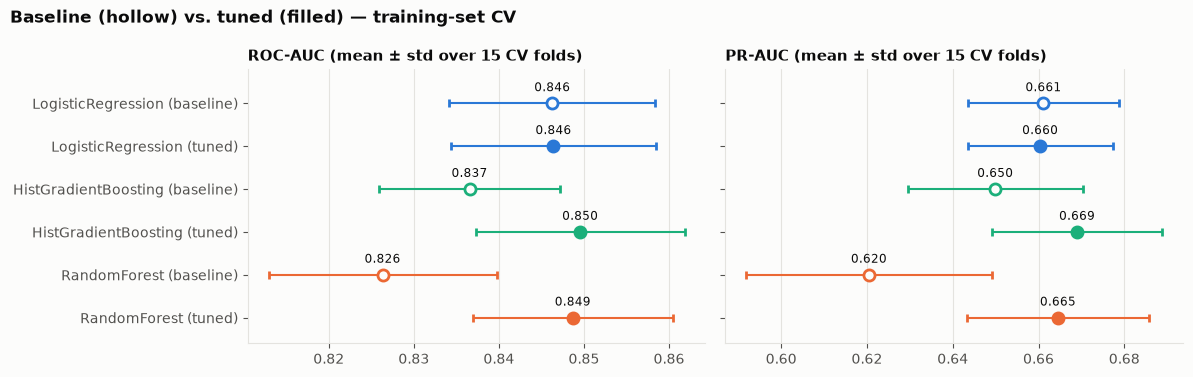

In [8]:
COLORS = {"LogisticRegression": "#2a78d6", "HistGradientBoosting": "#1baf7a", "RandomForest": "#eb6834"}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
labels = order[::-1]
for ax, metric, title in [(axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")]:
    for y, label in enumerate(labels):
        family, kind = label.split(" (")
        mean, std = summary.loc[label, (metric, "mean")], summary.loc[label, (metric, "std")]
        filled = kind.startswith("tuned")
        ax.errorbar(mean, y, xerr=std, fmt="o", markersize=8, capsize=3, color=COLORS[family],
                    markerfacecolor=COLORS[family] if filled else SURFACE, markeredgewidth=2)
        ax.text(mean, y + 0.28, f"{mean:.3f}", ha="center", fontsize=8.5, color=TEXT)
    ax.set_title(f"{title} (mean ± std over 15 CV folds)")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(len(labels)), labels)
axes[0].set_ylim(-0.6, len(labels) - 0.2)
fig.suptitle("Baseline (hollow) vs. tuned (filled) — training-set CV", x=0.01, ha="left", fontweight="bold", color=TEXT)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "19_tuned_vs_baseline_cv.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Apply the selection rule

In [9]:
tuned_names = [f"{m} (tuned)" for m in MODELS]
best_by_auc = summary.loc[tuned_names, ("roc_auc", "mean")].idxmax()
print(f"Highest evaluation-fold ROC-AUC among tuned models: {best_by_auc}")

if best_by_auc == "LogisticRegression (tuned)":
    final_label = best_by_auc
    reason = "tuned Logistic Regression has the highest CV ROC-AUC"
else:
    z = paired_table.loc[(f"{best_by_auc} − LogisticRegression (tuned)", "roc_auc"), "diff / SE"]
    final_label = best_by_auc if z >= 2 else "LogisticRegression (tuned)"
    reason = (f"{best_by_auc} beats tuned Logistic Regression by {z:.1f} SE "
              + ("(>= 2 SE: selected)" if z >= 2 else "(< 2 SE: prefer simpler tuned Logistic Regression)"))

FINAL_MODEL = final_label.split(" (")[0]
print(f"Final candidate: {final_label} — {reason}")
print("Hyperparameters:", best_params[FINAL_MODEL])

Highest evaluation-fold ROC-AUC among tuned models: HistGradientBoosting (tuned)
Final candidate: HistGradientBoosting (tuned) — HistGradientBoosting (tuned) beats tuned Logistic Regression by 3.2 SE (>= 2 SE: selected)
Hyperparameters: {'model__l2_regularization': np.float64(5.626265699005659), 'model__learning_rate': np.float64(0.015836308681309343), 'model__max_depth': 5, 'model__max_iter': 300, 'model__max_leaf_nodes': 7, 'model__min_samples_leaf': 200}


## 5. Re-select the operating threshold (out-of-fold, training set)

Same rule as Phase 6: the highest-precision threshold with out-of-fold recall ≥ 0.75, computed per CV repeat and averaged.

In [10]:
MIN_RECALL = 0.75
oof = tuned_cv.oof_predictions.query("model == @final_label")
per_repeat = pd.concat([
    threshold_table(part["y_true"], part["proba"]).assign(repeat=repeat) for repeat, part in oof.groupby("repeat")
])
thresholds = per_repeat.groupby("threshold")[["precision", "recall", "f1", "predicted_positive_rate"]].mean().reset_index()
thresholds.to_csv(REPORTS_DIR / "threshold_analysis_tuned.csv", index=False)

chosen_threshold = select_threshold_min_recall(thresholds, MIN_RECALL)
per_repeat_choice = {r: select_threshold_min_recall(p, MIN_RECALL) for r, p in per_repeat.groupby("repeat")}
print(f"Chosen threshold: {chosen_threshold:.2f}; per-repeat choices: {per_repeat_choice}")

at_threshold = pd.DataFrame([
    classification_metrics(part["y_true"], part["proba"], chosen_threshold) for _, part in oof.groupby("fold")
])
at_threshold.agg(["mean", "std"]).T

Chosen threshold: 0.30; per-repeat choices: {0: 0.3, 1: 0.3, 2: 0.3}


,mean,std
roc_auc,0.8496,0.0123
pr_auc,0.6690,0.0198
precision,0.5458,0.0169
recall,0.7596,0.0282
f1,0.6348,0.0128
brier,0.1337,0.0045
log_loss,0.4126,0.0127


## 6. Lock the training/CV decision

Recorded for Phase 9 (production pipeline). **Not evaluated on the test set in this phase.**

In [11]:
locked = {
    "model": FINAL_MODEL,
    "hyperparameters": {k: float(v) if isinstance(v, np.floating) else v
                        for k, v in best_params[FINAL_MODEL].items()},
    "threshold": chosen_threshold,
    "threshold_rule": f"highest precision with out-of-fold recall >= {MIN_RECALL}",
    "selection_rule": "highest CV ROC-AUC unless < 2 SE better than tuned Logistic Regression",
    "selection_reason": reason,
    "evidence": "training-set CV only (tuning seed %d; evaluation: repeated 5-fold x 3, seed 42)" % TUNING_CV_SEED,
    "cv_metrics_at_threshold": at_threshold.mean().round(4).to_dict(),
    "test_set_evaluated": False,
}
(REPORTS_DIR / "locked_decisions_tuned.json").write_text(json.dumps(locked, indent=2))
locked

{'model': 'HistGradientBoosting',
 'hyperparameters': {'model__l2_regularization': 5.626265699005659,
  'model__learning_rate': 0.015836308681309343,
  'model__max_depth': 5,
  'model__max_iter': 300,
  'model__max_leaf_nodes': 7,
  'model__min_samples_leaf': 200},
 'threshold': 0.3,
 'threshold_rule': 'highest precision with out-of-fold recall >= 0.75',
 'selection_rule': 'highest CV ROC-AUC unless < 2 SE better than tuned Logistic Regression',
 'selection_reason': 'HistGradientBoosting (tuned) beats tuned Logistic Regression by 3.2 SE (>= 2 SE: selected)',
 'evidence': 'training-set CV only (tuning seed 43; evaluation: repeated 5-fold x 3, seed 42)',
 'cv_metrics_at_threshold': {'roc_auc': 0.8496,
  'pr_auc': 0.669,
  'precision': 0.5458,
  'recall': 0.7596,
  'f1': 0.6348,
  'brier': 0.1337,
  'log_loss': 0.4126},
 'test_set_evaluated': False}

## 7. Findings

**Tuning fixed the tree models' overfitting.** Train − validation ROC-AUC gap: HistGradientBoosting 0.126 → 0.016, RandomForest 0.174 → 0.031. Both improved on every metric in 15/15 paired folds (ROC-AUC +0.013 and +0.022). The winning settings are heavily regularised: HistGradientBoosting uses 7-leaf trees, ≥ 200 samples per leaf, strong L2 and a low learning rate; RandomForest needs ≥ 20 samples per leaf.

**Logistic Regression was already at its ceiling.** ROC-AUC is flat across C = 0.1–10 and L1 vs. L2 (differences ≤ 0.0003). The best value (C = 10, L2) is at the edge of the grid, but the curve is flat, so extending the grid would not matter. Tuned vs. baseline: +0.0001 ROC-AUC (within noise).

**Selected by the pre-stated rule: tuned HistGradientBoosting.** Paired vs. tuned Logistic Regression: ROC-AUC +0.003 (3.2 SE, better in 12/15 folds), PR-AUC +0.009 (3.7 SE), and slightly better Brier score and log loss.

**Is the improvement material?** Statistically consistent, practically small. Compared with the Phase 6 locked baseline, ROC-AUC rises from 0.846 to 0.850 and PR-AUC from 0.661 to 0.669. The model has more hyperparameters, and it was chosen as the best of 25 configurations, so part of this small edge may be selection optimism that separate search and evaluation folds reduce but do not remove. Tuned Logistic Regression remains a near-equivalent, more interpretable fallback.

**Threshold (Phase 6 rule, out-of-fold):** 0.30, chosen identically in all 3 repeats. At 0.30: recall 0.760, precision 0.546, F1 0.635 (CV means), essentially the same operating point as the baseline (threshold 0.31: recall 0.758, precision 0.548).

**Not done here:** no test-set evaluation. If the tuned model is later evaluated on the test set, that is a *second* look at the same held-out data (Phase 6 was the first) and must be reported as such.